# F1 Corner Clustering -- WIP

In [1]:
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

import fastf1

from corner_utils import compute_curvature, detect_corners, KNOWN_CORNER_COUNTS

# Theme
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#111111',
    'axes.edgecolor':    '#333',
    'axes.labelcolor':   '#ccc',
    'text.color':        'white',
    'xtick.color':       '#888',
    'ytick.color':       '#888',
    'grid.color':        '#2a2a2a',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.4,
    'axes.grid':         False,
    'legend.facecolor':  '#1a1a1a',
    'legend.edgecolor':  '#444',
    'font.family':       'comic sans ms',
})

In [2]:
YEAR      = 2024
SESSION   = 'Q'
CACHE_DIR = './cashe/f1_casche'

# Colors for corner direction
COL_LEFT  = '#32a852'
COL_RIGHT = '#db1226'

# Per-circuit overrides (leave empty to use KNOWN_CORNER_COUNTS)
CORNER_COUNT_OVERRIDES = {}

os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

schedule = fastf1.get_event_schedule(YEAR, include_testing=False)
TRACKS   = schedule['EventName'].tolist()

print(f'{len(TRACKS)} events  --  {YEAR} {SESSION}')
for t in TRACKS:
    print(f'  {t}')

24 events  --  2024 Q
  Bahrain Grand Prix
  Saudi Arabian Grand Prix
  Australian Grand Prix
  Japanese Grand Prix
  Chinese Grand Prix
  Miami Grand Prix
  Emilia Romagna Grand Prix
  Monaco Grand Prix
  Canadian Grand Prix
  Spanish Grand Prix
  Austrian Grand Prix
  British Grand Prix
  Hungarian Grand Prix
  Belgian Grand Prix
  Dutch Grand Prix
  Italian Grand Prix
  Azerbaijan Grand Prix
  Singapore Grand Prix
  United States Grand Prix
  Mexico City Grand Prix
  São Paulo Grand Prix
  Las Vegas Grand Prix
  Qatar Grand Prix
  Abu Dhabi Grand Prix


## Corner Detection

For each circuit we load the fastest qualifying lap, compute signed curvature from GPS coordinates, and detect corner apexes using `detect_corners()` with a calibrated prominence threshold.

In [3]:
circuit_data  = {}
failed_tracks = []

for gp in TRACKS:
    try:
        session = fastf1.get_session(YEAR, gp, SESSION)
        session.load(telemetry=True, laps=True, weather=False, messages=False)

        fastest = session.laps.pick_fastest()
        if fastest is None or (isinstance(fastest, pd.Series) and fastest.empty):
            fastest = session.laps.sort_values('LapTime').iloc[0]

        tel   = fastest.get_telemetry().add_distance()
        x_raw = tel['X'].values.astype(float)
        y_raw = tel['Y'].values.astype(float)
        dist  = tel['Distance'].values.astype(float)
        speed = tel['Speed'].values.astype(float)

        kappa, x_s, y_s = compute_curvature(x_raw, y_raw)
        kappa_smooth     = gaussian_filter1d(kappa, sigma=5)
        abs_kappa        = np.abs(kappa_smooth)

        if 'Steering' in tel.columns:
            steer_arr  = tel['Steering'].values.astype(float)
            steer_dist = tel['Distance'].values.astype(float)
        else:
            steer_arr = steer_dist = None

        target  = CORNER_COUNT_OVERRIDES.get(gp) or KNOWN_CORNER_COUNTS.get(gp)
        corners = detect_corners(abs_kappa, dist, speed, kappa_smooth,
                                 target_count=target,
                                 steering_arr=steer_arr,
                                 steer_dist=steer_dist)

        circuit_data[gp] = {
            'x_s':    x_s,
            'y_s':    y_s,
            'dist':   dist,
            'speed':  speed,
            'kappa':  kappa_smooth,
            'corners': corners,
            'driver':  fastest['Driver'],
            'target':  target,
        }

        match = '' if target is None else (' ok' if len(corners) == target else f' (target {target})')
        print(f'  {gp:30s}  {len(corners):2d} corners  [{fastest["Driver"]}]{match}')

    except Exception as exc:
        warnings.warn(f'SKIP {gp}: {exc}')
        failed_tracks.append(gp)

print(f'\nLoaded {len(circuit_data)} circuits')
if failed_tracks:
    print(f'Skipped: {failed_tracks}')

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]


req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:108: UserWarning: Corner calibration: target=15, achieved=13 (closest possible)
  warnings.warn(
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INF

  Bahrain Grand Prix              13 corners  [LEC] (target 15)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:108: UserWarning: Corner calibration: target=27, achieved=19 (closest possible)
  warnings.warn(
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  Saudi Arabian Grand Prix        19 corners  [VER] (target 27)


...

req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '4', '81', '16', '44', '55', '14', '11', '20', '10', '24', '77', '22', '18', '23', '30', '27', '43', '31']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:108: UserWarning: Corner calibration: target=16, achieved=13 (closest possible)
  warnings.warn(
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  Qatar Grand Prix                13 corners  [VER] (target 16)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '55', '27', '1', '10', '63', '14', '77', '11', '22', '30', '18', '16', '20', '23', '24', '44', '43', '61']


  Abu Dhabi Grand Prix            13 corners  [NOR] (target 16)

Loaded 24 circuits


c:\Users\Harrison\Desktop\Clustering\corner_utils.py:108: UserWarning: Corner calibration: target=16, achieved=13 (closest possible)
  warnings.warn(


In [4]:
# Checking recognized corner counts against known data

rows = []
for gp, d in circuit_data.items():
    n_det    = len(d['corners'])
    official = d['target']
    n_left   = sum(1 for c in d['corners'] if c['direction'] == 'L')
    n_right  = len(d['corners']) - n_left
    rows.append({
        'Circuit':          gp,
        'Detected':         n_det,
        'Official':         official if official else '--',
        'Match':            'OK' if official and n_det == official else ('--' if not official else -1 * (official - n_det)),
        'Left (teal)':      n_left,
        'Right (red)':      n_right,
        'Fastest driver':   d['driver'],
    })

summary = pd.DataFrame(rows).set_index('Circuit')
print(summary.to_string())

                           Detected  Official Match  Left (teal)  Right (red) Fastest driver
Circuit                                                                                     
Bahrain Grand Prix               13        15    -2            5            8            LEC
Saudi Arabian Grand Prix         19        27    -8           11            8            VER
Australian Grand Prix            15        16    -1            5           10            VER
Japanese Grand Prix              15        18    -3            7            8            VER
Chinese Grand Prix               10        16    -6            5            5            VER
Miami Grand Prix                 15        19    -4            9            6            VER
Emilia Romagna Grand Prix        17        19    -2           10            7            VER
Monaco Grand Prix                14        19    -5            5            9            LEC
Canadian Grand Prix              13        13    OK            6      

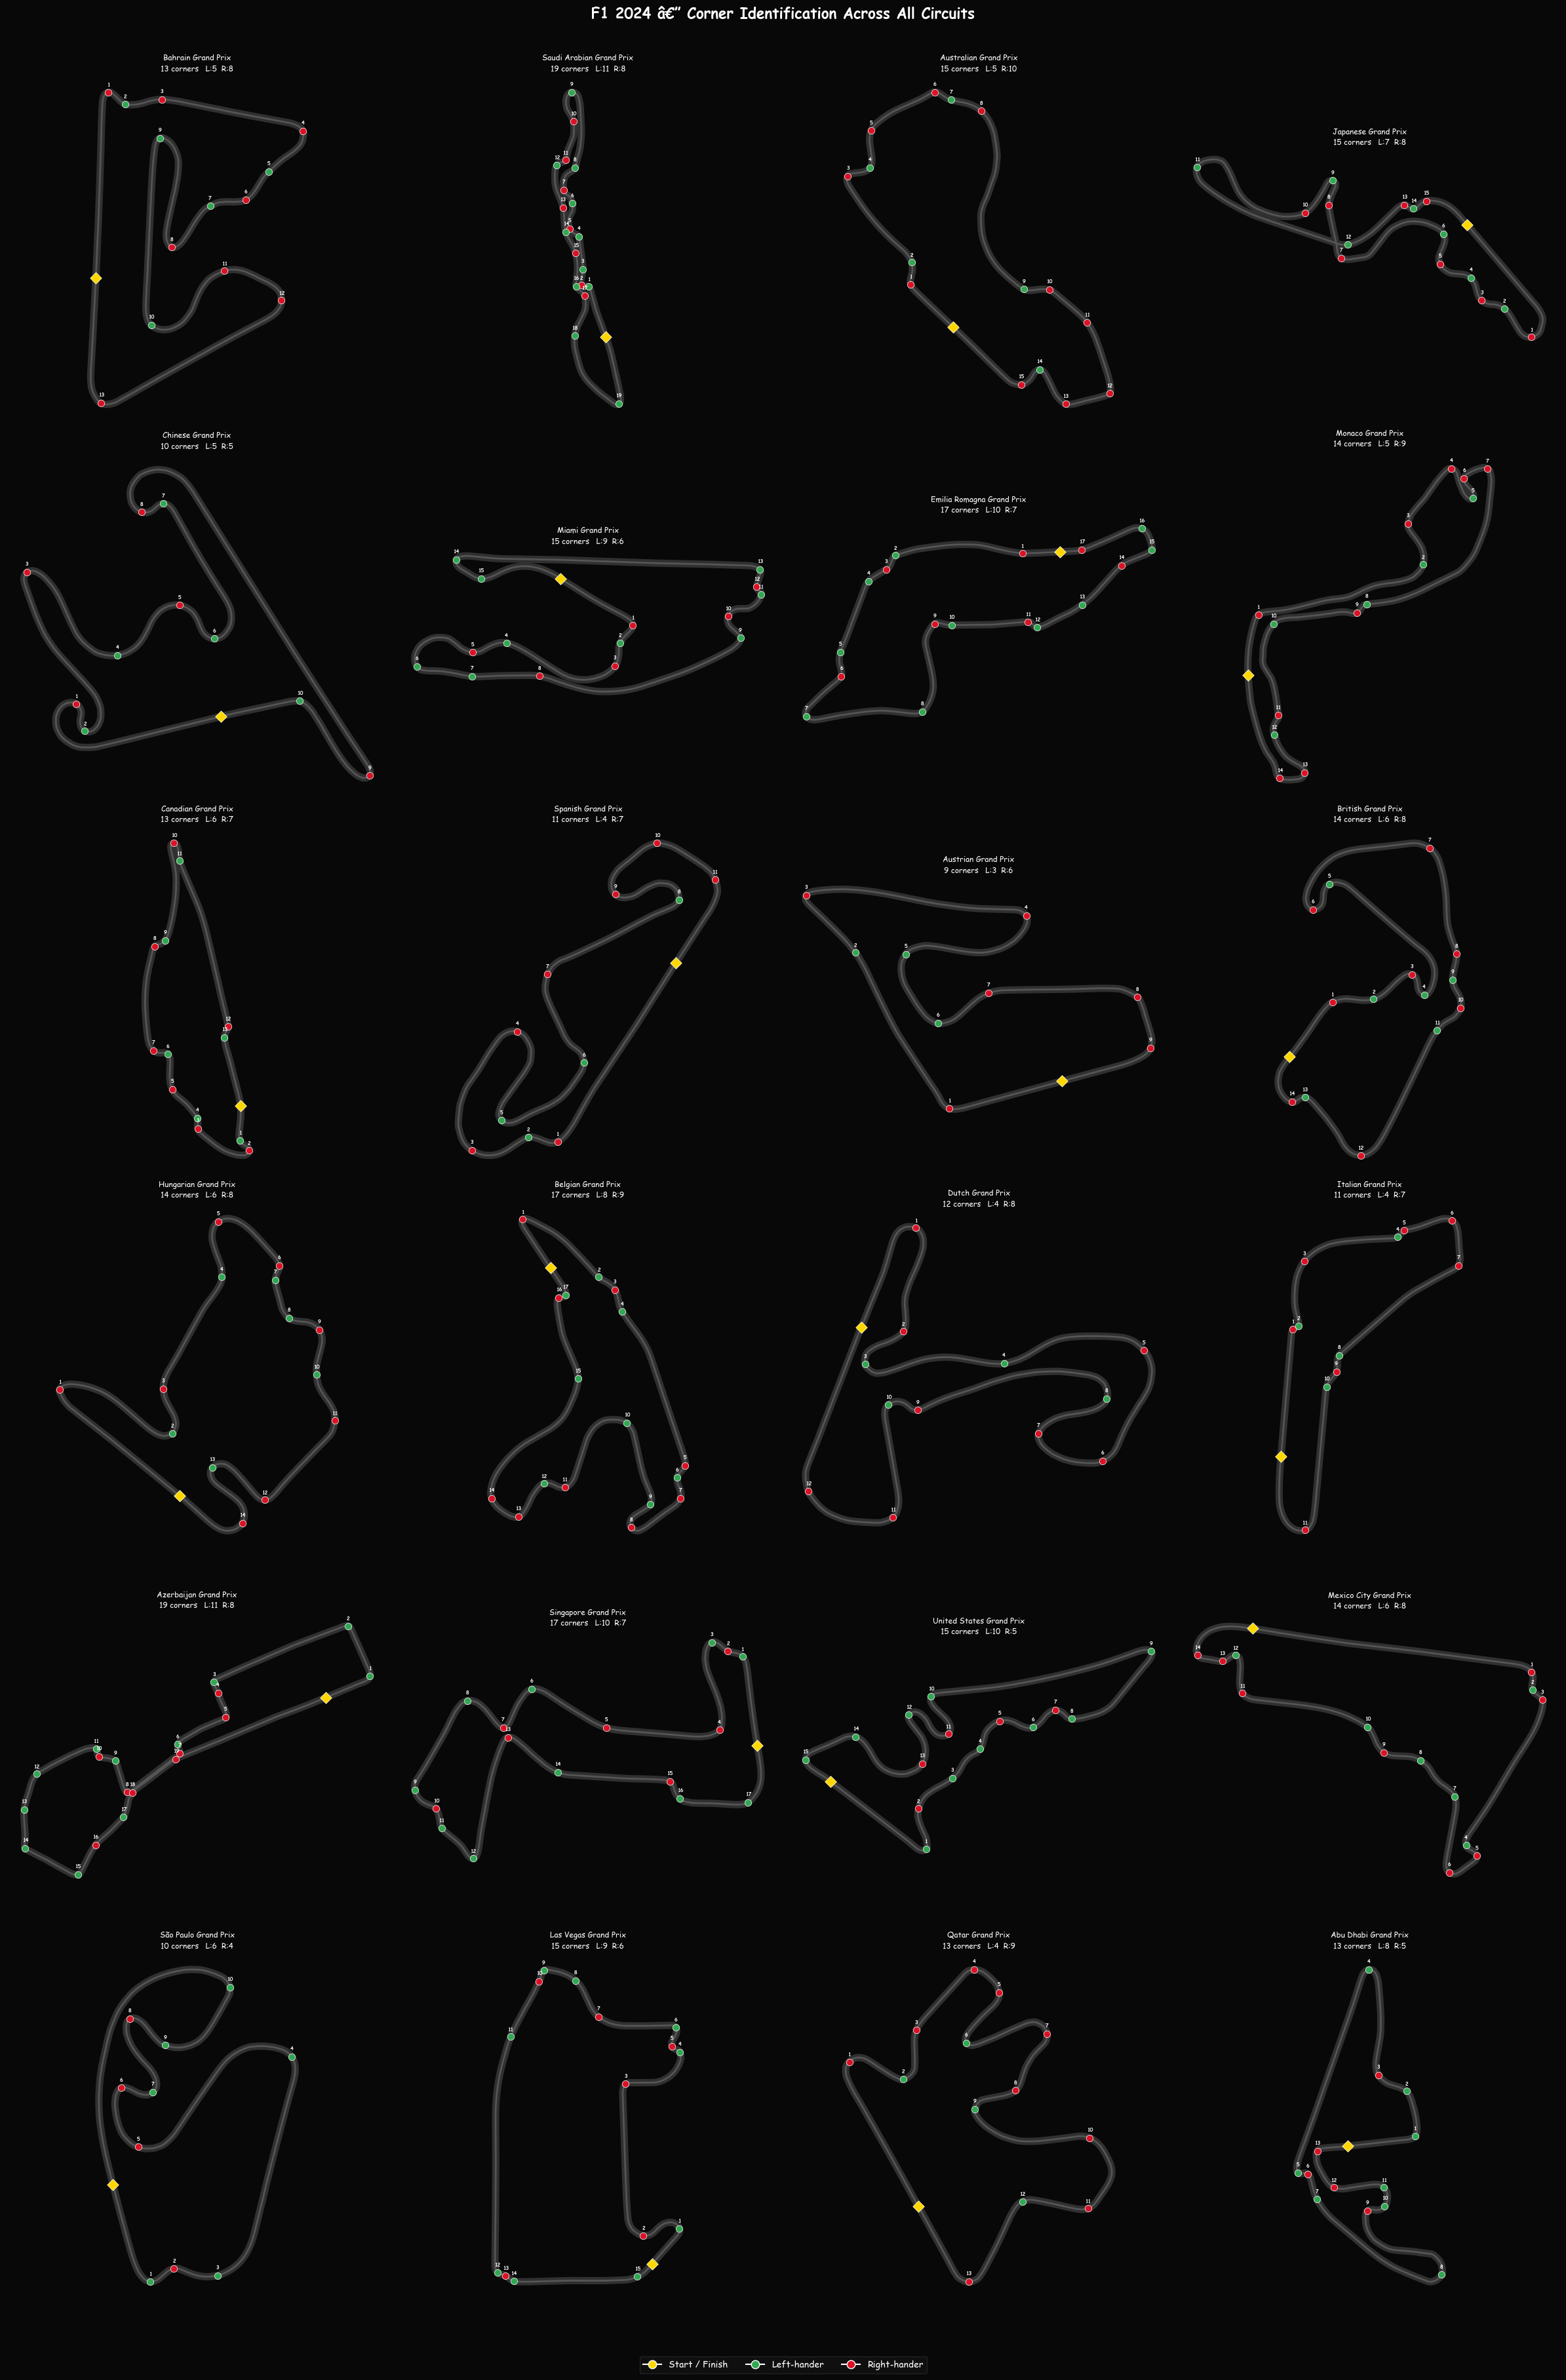

Saved corner_map_grid.png


In [5]:
# Track Maps

loaded = list(circuit_data.keys())
n_circ = len(loaded)
n_cols = 4
n_rows = int(np.ceil(n_circ / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 6 * n_rows),
    squeeze=False,
)
fig.patch.set_facecolor('#080808')

for idx, gp in enumerate(loaded):
    ri, ci = divmod(idx, n_cols)
    ax = axes[ri][ci]
    d  = circuit_data[gp]
    x_s, y_s, corners = d['x_s'], d['y_s'], d['corners']

    ax.set_facecolor('#0d0d0d')
    ax.set_aspect('equal')
    ax.axis('off')

    # Track outline
    ax.plot(x_s, y_s, color='#303030', linewidth=8, solid_capstyle='round', zorder=1)
    ax.plot(x_s, y_s, color='#555',    linewidth=2, solid_capstyle='round', zorder=2)

    # Start-finish marker
    ax.scatter(x_s[0], y_s[0], s=80, color='#ffd700',
               zorder=5, marker='D', edgecolors='white', linewidths=0.5)

    # Corner apexes
    for c in corners:
        color = COL_LEFT if c['direction'] == 'L' else COL_RIGHT
        xi, yi = x_s[c['apex_idx']], y_s[c['apex_idx']]
        ax.scatter(xi, yi, s=55, color=color,
                   edgecolors='white', linewidths=0.5, zorder=4)
        ax.annotate(
            str(c['corner_num']),
            (xi, yi), xytext=(0, 7),
            textcoords='offset points',
            ha='center', fontsize=5.5,
            color='white', fontweight='bold', zorder=6,
        )

    n_l = sum(1 for c in corners if c['direction'] == 'L')
    n_r = len(corners) - n_l
    ax.set_title(
        f'{gp}\n{len(corners)} corners   L:{n_l}  R:{n_r}',
        color='white', fontsize=8.5, pad=6, linespacing=1.5,
    )
for idx in range(n_circ, n_rows * n_cols):
    ri, ci = divmod(idx, n_cols)
    axes[ri][ci].set_visible(False)

# Legend
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ffd700',
           markersize=9, label='Start / Finish'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_LEFT,
           markersize=9, label='Left-hander'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_RIGHT,
           markersize=9, label='Right-hander'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.4, bbox_to_anchor=(0.5, 0.0))

fig.suptitle(
    f'F1 {YEAR} -- Corner Identification Across All Circuits',
    fontsize=16, color='white', y=1.005, fontweight='bold',
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('Maps/grid_maps/corner_map_grid.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved Maps/grid_maps/corner_map_grid.png')

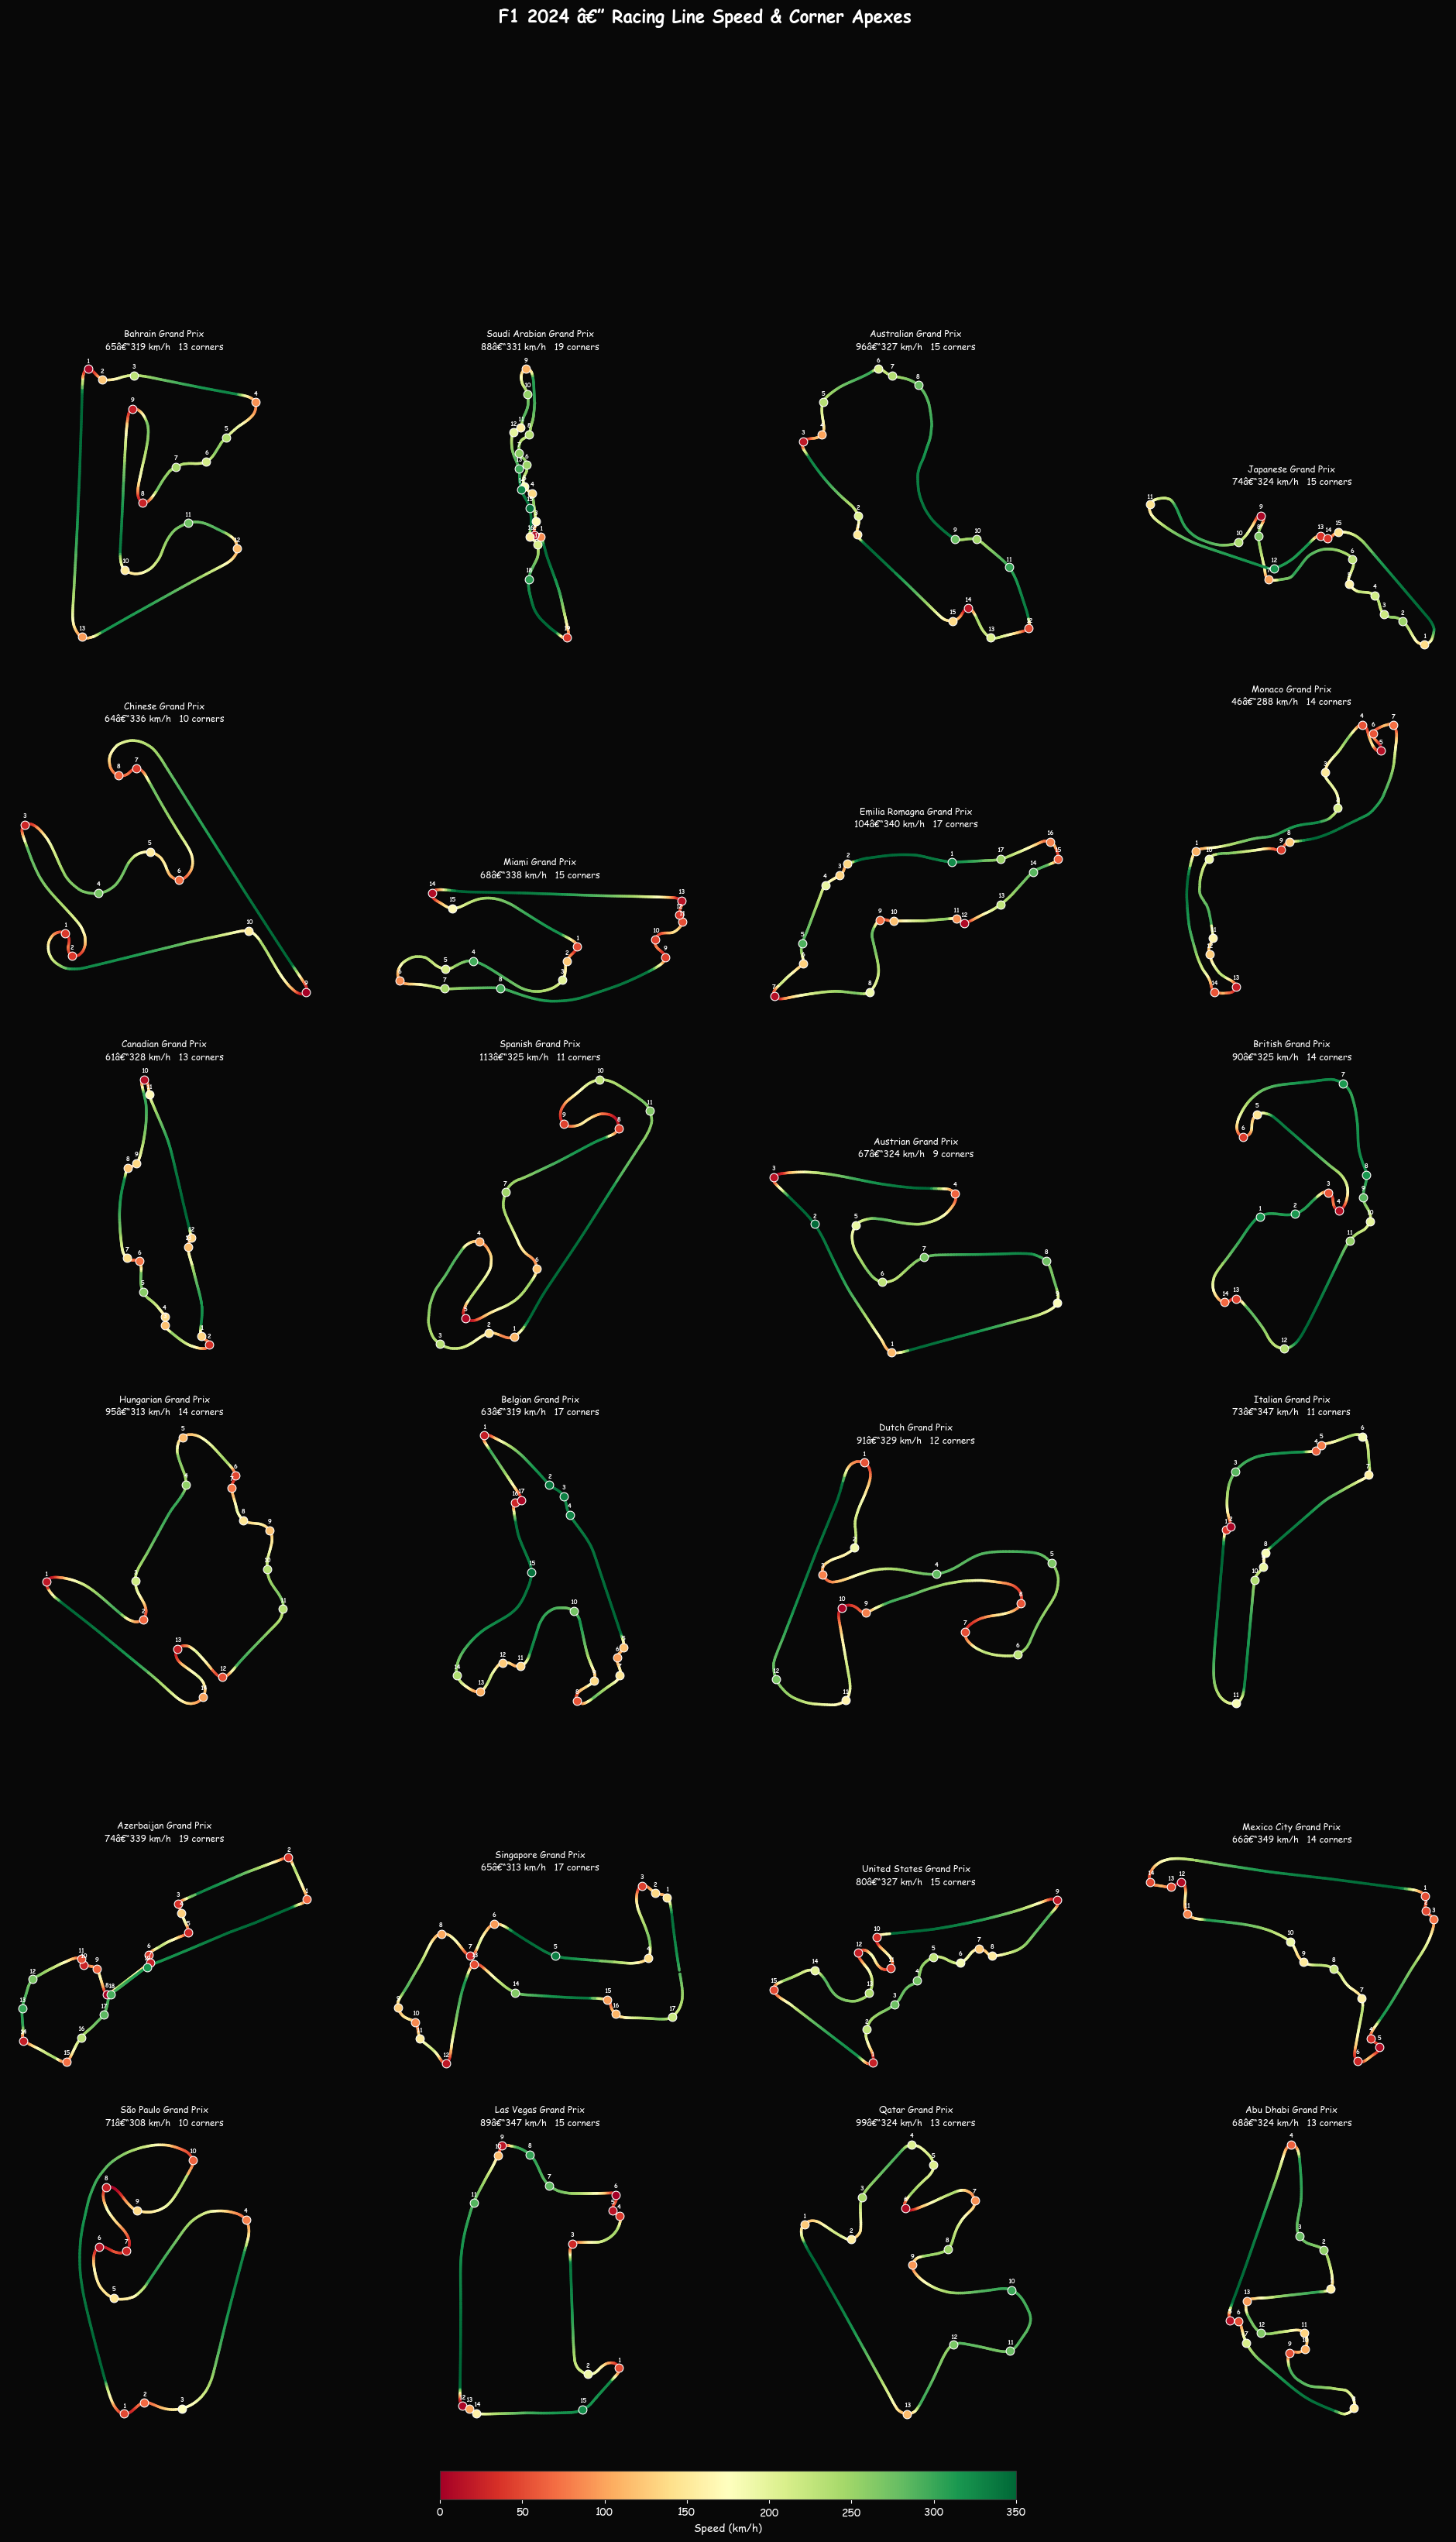

Saved -> corner_speed_grid.png


In [6]:
# Speed Trace maps

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

CMAP = cm.RdYlGn   # red=slow, green=fast

n_cols_s = 4
n_rows_s = int(np.ceil(n_circ / n_cols_s))

fig, axes = plt.subplots(
    n_rows_s, n_cols_s,
    figsize=(6 * n_cols_s, 6 * n_rows_s),
    squeeze=False,
)
fig.patch.set_facecolor('#080808')

for idx, gp in enumerate(loaded):
    ri, ci = divmod(idx, n_cols_s)
    ax = axes[ri][ci]
    d  = circuit_data[gp]
    x_s, y_s, speed, corners = d['x_s'], d['y_s'], d['speed'], d['corners']

    ax.set_facecolor('#0d0d0d')
    ax.set_aspect('equal')
    ax.axis('off')

    # Build speed-colored LineCollection
    pts    = np.array([x_s, y_s]).T.reshape(-1, 1, 2)
    segs   = np.concatenate([pts[:-1], pts[1:]], axis=1)
    norm   = Normalize(vmin=speed.min(), vmax=speed.max())
    cols   = CMAP(norm(speed[:-1]))
    lc     = LineCollection(segs, colors=cols, linewidth=2.5,
                            capstyle='round', zorder=2)
    ax.add_collection(lc)
    ax.autoscale_view()

    # Corner apexes
    for c in corners:
        xi, yi = x_s[c['apex_idx']], y_s[c['apex_idx']]
        sp     = speed[c['apex_idx']]
        ax.scatter(xi, yi, s=60, color=CMAP(norm(sp)),
                   edgecolors='white', linewidths=0.8, zorder=4)
        ax.annotate(
            str(c['corner_num']),
            (xi, yi), xytext=(0, 7),
            textcoords='offset points',
            ha='center', fontsize=5.5,
            color='white', fontweight='bold', zorder=5,
        )

    v_min, v_max = int(speed.min()), int(speed.max())
    ax.set_title(
        f'{gp}\n{v_min}-{v_max} km/h   {len(corners)} corners',
        color='white', fontsize=8.5, pad=6, linespacing=1.5,
    )

for idx in range(n_circ, n_rows_s * n_cols_s):
    ri, ci = divmod(idx, n_cols_s)
    axes[ri][ci].set_visible(False)

# Shared coloubar
sm = ScalarMappable(cmap=CMAP, norm=Normalize(vmin=0, vmax=350))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal',
                    fraction=0.015, pad=0.02, shrink=0.4)
cbar.set_label('Speed (km/h)', color='white', fontsize=10)
cbar.ax.xaxis.set_tick_params(color='white')
plt.setp(cbar.ax.xaxis.get_ticklabels(), color='white')

fig.suptitle(
    f'F1 {YEAR} -- Racing Line Speed & Corner Apexes',
    fontsize=16, color='white', y=1.005, fontweight='bold',
)
plt.savefig('Maps/grid_maps/corner_speed_grid.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved -> corner_speed_grid.png')

In [7]:
# Individual circuit maps

os.makedirs('Maps/individual_circuits', exist_ok=True)

for gp, d in circuit_data.items():
    x_s, y_s, speed, corners = d['x_s'], d['y_s'], d['speed'], d['corners']

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.patch.set_facecolor('#0a0a0a')
    fig.suptitle(gp, fontsize=18, color='white', fontweight='bold', y=1.01)

    # -- Left panel: direction map ---------------------------------------------
    ax = axes[0]
    ax.set_facecolor('#0d0d0d')
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Corner directions', color='#aaa', fontsize=11, pad=8)

    ax.plot(x_s, y_s, color='#2a2a2a', linewidth=10, solid_capstyle='round', zorder=1)
    ax.plot(x_s, y_s, color='#555',    linewidth=2.5, zorder=2)
    ax.scatter(x_s[0], y_s[0], s=120, color='#ffd700', marker='D',
               edgecolors='white', linewidths=0.8, zorder=5)

    for c in corners:
        colour = COL_LEFT if c['direction'] == 'L' else COL_RIGHT
        xi, yi = x_s[c['apex_idx']], y_s[c['apex_idx']]
        ax.scatter(xi, yi, s=120, color=colour,
                   edgecolors='white', linewidths=0.8, zorder=4)
        ax.annotate(
            f"T{c['corner_num']}",
            (xi, yi), xytext=(0, 10),
            textcoords='offset points',
            ha='center', fontsize=8,
            color='white', fontweight='bold', zorder=6,
        )

    n_l = sum(1 for c in corners if c['direction'] == 'L')
    n_r = len(corners) - n_l
    ax.legend(
        handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_LEFT,
                   markersize=10, label=f'Left-hander  ({n_l})'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_RIGHT,
                   markersize=10, label=f'Right-hander ({n_r})'),
            Line2D([0],[0], marker='D', color='w', markerfacecolor='#ffd700',
                   markersize=10, label='Start / Finish'),
        ],
        loc='best', fontsize=9, framealpha=0.4,
    )

    # -- Right panel: speed map ------------------------------------------------
    ax2 = axes[1]
    ax2.set_facecolor('#0d0d0d')
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title('Racing line speed', color='#aaa', fontsize=11, pad=8)

    pts  = np.array([x_s, y_s]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    norm = Normalize(vmin=speed.min(), vmax=speed.max())
    lc   = LineCollection(segs, colors=CMAP(norm(speed[:-1])),
                          linewidth=3, capstyle='round', zorder=2)
    ax2.add_collection(lc)
    ax2.autoscale_view()

    for c in corners:
        xi, yi = x_s[c['apex_idx']], y_s[c['apex_idx']]
        sp = speed[c['apex_idx']]
        ax2.scatter(xi, yi, s=120, color=CMAP(norm(sp)),
                    edgecolors='white', linewidths=0.8, zorder=4)
        ax2.annotate(
            f"T{c['corner_num']}\n{int(sp)}",
            (xi, yi), xytext=(0, 11),
            textcoords='offset points',
            ha='center', fontsize=7,
            color='white', zorder=5,
        )

    sm2  = ScalarMappable(cmap=CMAP, norm=norm)
    sm2.set_array([])
    cbar2 = fig.colorbar(sm2, ax=ax2, orientation='vertical',
                         fraction=0.03, pad=0.02, shrink=0.7)
    cbar2.set_label('Speed (km/h)', color='white', fontsize=9)
    cbar2.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')

    plt.tight_layout()
    safe_name = gp.replace(' ', '_').replace('/', '-')
    fig.savefig(f'Maps/individual_circuits/{safe_name}.png', dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f'  Saved Maps/individual_circuits/{safe_name}.png')

print(f'\nDone -- {len(circuit_data)} circuit maps saved to Maps/individual_circuits/')

  Saved circuit_maps/Bahrain_Grand_Prix.png
  Saved circuit_maps/Saudi_Arabian_Grand_Prix.png
  Saved circuit_maps/Australian_Grand_Prix.png
  Saved circuit_maps/Japanese_Grand_Prix.png
  Saved circuit_maps/Chinese_Grand_Prix.png
  Saved circuit_maps/Miami_Grand_Prix.png
  Saved circuit_maps/Emilia_Romagna_Grand_Prix.png
  Saved circuit_maps/Monaco_Grand_Prix.png
  Saved circuit_maps/Canadian_Grand_Prix.png
  Saved circuit_maps/Spanish_Grand_Prix.png
  Saved circuit_maps/Austrian_Grand_Prix.png
  Saved circuit_maps/British_Grand_Prix.png
  Saved circuit_maps/Hungarian_Grand_Prix.png
  Saved circuit_maps/Belgian_Grand_Prix.png
  Saved circuit_maps/Dutch_Grand_Prix.png
  Saved circuit_maps/Italian_Grand_Prix.png
  Saved circuit_maps/Azerbaijan_Grand_Prix.png
  Saved circuit_maps/Singapore_Grand_Prix.png
  Saved circuit_maps/United_States_Grand_Prix.png
  Saved circuit_maps/Mexico_City_Grand_Prix.png
  Saved circuit_maps/São_Paulo_Grand_Prix.png
  Saved circuit_maps/Las_Vegas_Grand_Prix.p